In [3]:
import os
os.chdir('/Users/taruni/Desktop/virality-prediction-ml-2026')
print('Working directory:', os.getcwd())

Working directory: /Users/taruni/Desktop/virality-prediction-ml-2026


# 01 — Exploratory Data Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

In [7]:
# Load all three datasets
instagram_df = pd.read_csv('data/raw/Instagram_Analytics.csv')
youtube_df   = pd.read_csv('data/raw/USvideos.csv', encoding='latin-1')
tiktok_df    = pd.read_csv('data/raw/tiktok_dataset.csv')

print('Instagram:', instagram_df.shape)
print('YouTube:  ', youtube_df.shape)
print('TikTok:   ', tiktok_df.shape)

Instagram: (29999, 23)
YouTube:   (40949, 16)
TikTok:    (19382, 12)


In [8]:
# ── INSTAGRAM ──
print("=== INSTAGRAM ===")
print(instagram_df.columns.tolist())
print()
instagram_df.head(3)

=== INSTAGRAM ===
['post_id', 'account_id', 'account_type', 'follower_count', 'media_type', 'content_category', 'traffic_source', 'has_call_to_action', 'post_datetime', 'post_date', 'post_hour', 'day_of_week', 'likes', 'comments', 'shares', 'saves', 'reach', 'impressions', 'engagement_rate', 'followers_gained', 'caption_length', 'hashtags_count', 'performance_bucket_label']



,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,post_hour,day_of_week,likes,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,6,Saturday,194,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,15,Friday,449,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,16,Thursday,114,2,1,22,1639,2616,0.0531,758,115,8,high


In [9]:
# ── YOUTUBE ──
print("=== YOUTUBE ===")
print(youtube_df.columns.tolist())
print()
youtube_df.head(3)

=== YOUTUBE ===
['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description']



,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...


In [10]:
# ── TIKTOK ──
print("=== TIKTOK ===")
print(tiktok_df.columns.tolist())
print()
tiktok_df.head(3)

=== TIKTOK ===
['#', 'claim_status', 'video_id', 'video_duration_sec', 'video_transcription_text', 'verified_status', 'author_ban_status', 'video_view_count', 'video_like_count', 'video_share_count', 'video_download_count', 'video_comment_count']



,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0


In [11]:
# ── MISSING VALUES ──
print("=== INSTAGRAM missing values ===")
print(instagram_df.isnull().sum())
print()

print("=== YOUTUBE missing values ===")
print(youtube_df.isnull().sum())
print()

print("=== TIKTOK missing values ===")
print(tiktok_df.isnull().sum())

=== INSTAGRAM missing values ===
post_id                     0
account_id                  0
account_type                0
follower_count              0
media_type                  0
content_category            0
traffic_source              0
has_call_to_action          0
post_datetime               0
post_date                   0
post_hour                   0
day_of_week                 0
likes                       0
comments                    0
shares                      0
saves                       0
reach                       0
impressions                 0
engagement_rate             0
followers_gained            0
caption_length              0
hashtags_count              0
performance_bucket_label    0
dtype: int64

=== YOUTUBE missing values ===
video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                 

In [12]:
# ── ENGAGEMENT STATS ──
print("=== INSTAGRAM engagement_rate stats ===")
print(instagram_df['engagement_rate'].describe())
print()

print("=== YOUTUBE engagement stats ===")
youtube_df['engagement_rate'] = (youtube_df['likes'] + youtube_df['comment_count']) / youtube_df['views']
print(youtube_df['engagement_rate'].describe())
print()

print("=== TIKTOK engagement stats ===")
tiktok_df_clean = tiktok_df.dropna()
tiktok_df_clean = tiktok_df_clean.copy()
tiktok_df_clean['engagement_rate'] = (tiktok_df_clean['video_like_count'] + tiktok_df_clean['video_comment_count']) / tiktok_df_clean['video_view_count']
print(tiktok_df_clean['engagement_rate'].describe())

=== INSTAGRAM engagement_rate stats ===
count    29999.000000
mean         0.042107
std          0.024095
min          0.000000
25%          0.024000
50%          0.040600
75%          0.057000
max          0.271000
Name: engagement_rate, dtype: float64

=== YOUTUBE engagement stats ===
count    40949.000000
mean         0.038866
std          0.029916
min          0.000000
25%          0.017724
50%          0.032022
75%          0.051951
max          0.325928
Name: engagement_rate, dtype: float64

=== TIKTOK engagement stats ===
count    19084.000000
mean         0.277047
std          0.173721
min          0.000000
25%          0.130826
50%          0.264921
75%          0.399846
max          0.674847
Name: engagement_rate, dtype: float64


In [13]:
# ── VIRALITY LABELS ──

# Instagram - already has engagement_rate
ig_threshold = instagram_df['engagement_rate'].quantile(0.80)
instagram_df['viral'] = (instagram_df['engagement_rate'] > ig_threshold).astype(int)
print(f"Instagram threshold (p80): {ig_threshold:.4f}")
print(instagram_df['viral'].value_counts())
print()

# YouTube
yt_threshold = youtube_df['engagement_rate'].quantile(0.80)
youtube_df['viral'] = (youtube_df['engagement_rate'] > yt_threshold).astype(int)
print(f"YouTube threshold (p80): {yt_threshold:.4f}")
print(youtube_df['viral'].value_counts())
print()

# TikTok
tt_threshold = tiktok_df_clean['engagement_rate'].quantile(0.80)
tiktok_df_clean['viral'] = (tiktok_df_clean['engagement_rate'] > tt_threshold).astype(int)
print(f"TikTok threshold (p80): {tt_threshold:.4f}")
print(tiktok_df_clean['viral'].value_counts())

Instagram threshold (p80): 0.0603
viral
0    24035
1     5964
Name: count, dtype: int64

YouTube threshold (p80): 0.0574
viral
0    32759
1     8190
Name: count, dtype: int64

TikTok threshold (p80): 0.4274
viral
0    15267
1     3817
Name: count, dtype: int64


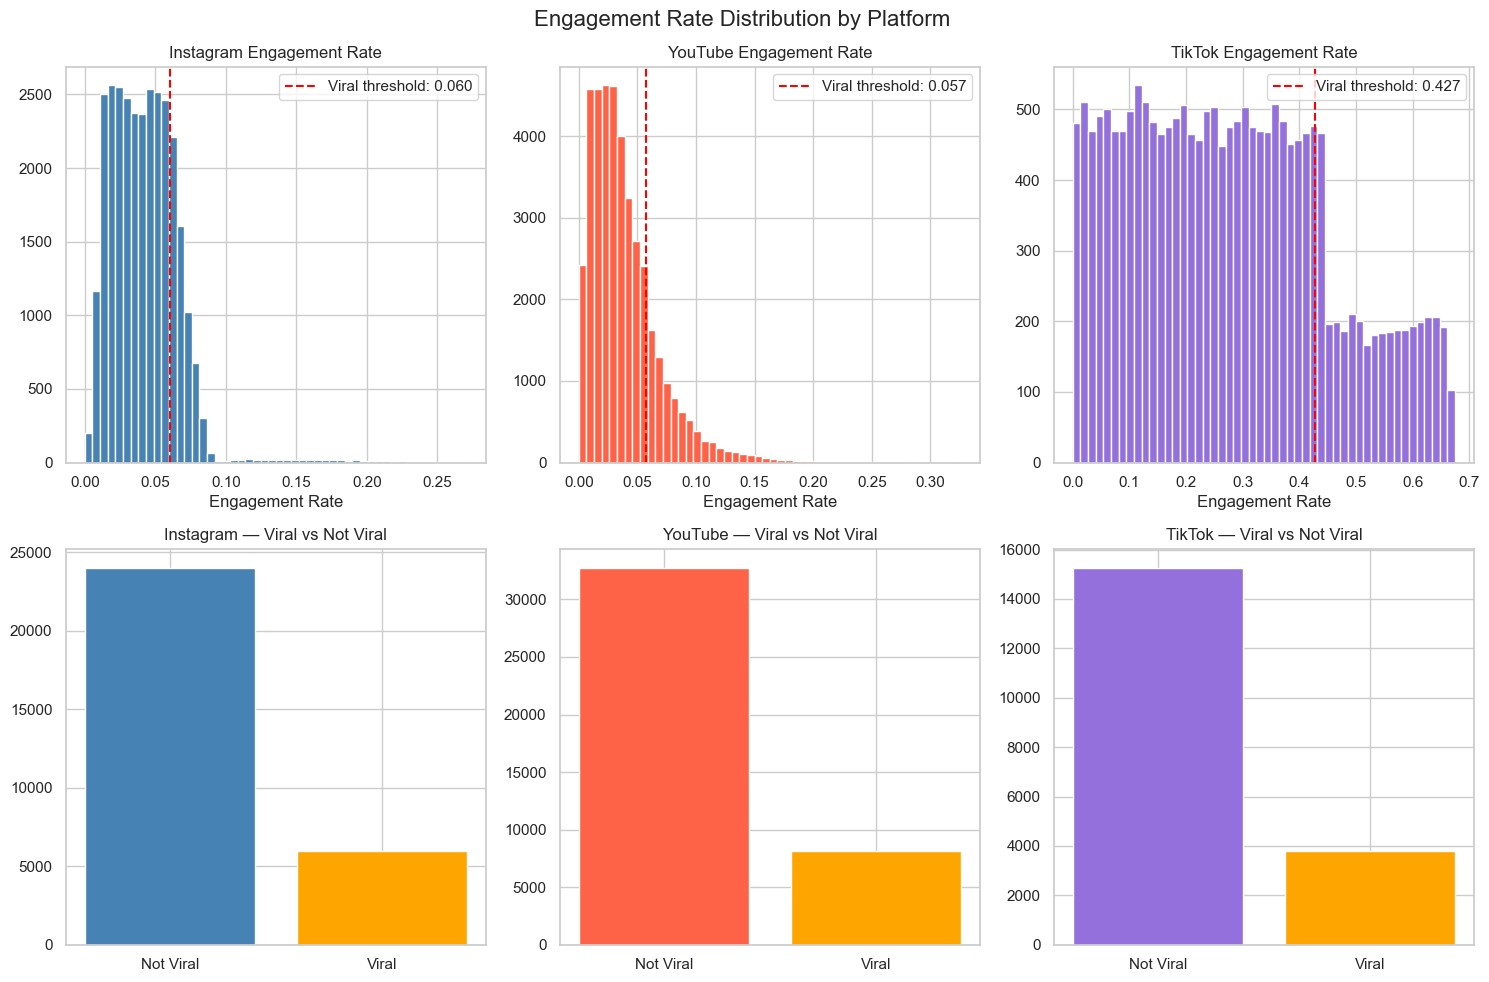

Plot saved!


In [14]:
# ── VISUALIZATIONS ──
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Engagement Rate Distribution by Platform', fontsize=16)

# Engagement rate distributions
axes[0,0].hist(instagram_df['engagement_rate'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Instagram Engagement Rate')
axes[0,0].set_xlabel('Engagement Rate')
axes[0,0].axvline(ig_threshold, color='red', linestyle='--', label=f'Viral threshold: {ig_threshold:.3f}')
axes[0,0].legend()

axes[0,1].hist(youtube_df['engagement_rate'], bins=50, color='tomato', edgecolor='white')
axes[0,1].set_title('YouTube Engagement Rate')
axes[0,1].set_xlabel('Engagement Rate')
axes[0,1].axvline(yt_threshold, color='red', linestyle='--', label=f'Viral threshold: {yt_threshold:.3f}')
axes[0,1].legend()

axes[0,2].hist(tiktok_df_clean['engagement_rate'], bins=50, color='mediumpurple', edgecolor='white')
axes[0,2].set_title('TikTok Engagement Rate')
axes[0,2].set_xlabel('Engagement Rate')
axes[0,2].axvline(tt_threshold, color='red', linestyle='--', label=f'Viral threshold: {tt_threshold:.3f}')
axes[0,2].legend()

# Viral vs not viral counts
axes[1,0].bar(['Not Viral', 'Viral'], instagram_df['viral'].value_counts().sort_index(), color=['steelblue','orange'])
axes[1,0].set_title('Instagram — Viral vs Not Viral')

axes[1,1].bar(['Not Viral', 'Viral'], youtube_df['viral'].value_counts().sort_index(), color=['tomato','orange'])
axes[1,1].set_title('YouTube — Viral vs Not Viral')

axes[1,2].bar(['Not Viral', 'Viral'], tiktok_df_clean['viral'].value_counts().sort_index(), color=['mediumpurple','orange'])
axes[1,2].set_title('TikTok — Viral vs Not Viral')

plt.tight_layout()
plt.savefig('notebooks/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")